## Diversity-metric sweep analysis

This notebook loads all `04_diversity_metric*.json` artifacts across every `context_*` folder,
extracts `(model, temperature, prompt_type)`, builds a dataframe containing the **six** diversity
metrics, and plots each metric vs temperature — **one full set of figures per context**.

In [70]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns

    _HAVE_SEABORN = True
except Exception:
    sns = None
    _HAVE_SEABORN = False


REPO_ROOT = Path.cwd()
OUTPUTS_DIR = REPO_ROOT / "Persona_Generator" / "outputs"

# ── Context discovery ───────────────────────────────────────────────────────
# Load context.json for human-readable labels, then discover context_* folders.

_context_labels: dict[int, str] = {}
_context_json = OUTPUTS_DIR / "context.json"
if _context_json.exists():
    with _context_json.open("r", encoding="utf-8") as _f:
        for entry in json.load(_f).get("contexts", []):
            _context_labels[entry["context_id"]] = entry["context"]

_CONTEXT_DIR_RE = re.compile(r"^context_(\d+)$")

CONTEXT_DIRS: list[tuple[int, str, Path]] = []
for d in sorted(OUTPUTS_DIR.iterdir()):
    if d.is_dir():
        m = _CONTEXT_DIR_RE.match(d.name)
        if m:
            cid = int(m.group(1))
            label = _context_labels.get(cid, d.name)
            CONTEXT_DIRS.append((cid, label, d))

print(f"Discovered {len(CONTEXT_DIRS)} context folder(s):")
for cid, label, path in CONTEXT_DIRS:
    print(f"  context_{cid}: {label}")

# ── Stage-2 filename parsers ───────────────────────────────────────────────
_STAGE2_RE = re.compile(
    r"^02c_stage2_personas_(?P<model>.+?)T(?P<temp>[0-9]*\.?[0-9]+)_(?P<prompt_type>[^.]+)\.json$"
)
_STAGE2_LEGACY_RE = re.compile(
    r"^02c_stage2_personas_(?P<model>.+?)_(?P<prompt_type>[^.]+)\.json$"
)


METRIC_COLS = [
    "coverage",
    "convex_hull_volume",
    "min_pairwise_distance",
    "mean_pairwise_distance",
    "dispersion",
    "kl_divergence",
]


def _parse_stage2_id(stage2_filename: str) -> dict:
    m = _STAGE2_RE.match(stage2_filename)
    if m:
        return {
            "model": m.group("model"),
            "temp": float(m.group("temp")),
            "prompt_type": m.group("prompt_type"),
        }

    m = _STAGE2_LEGACY_RE.match(stage2_filename)
    if m:
        return {
            "model": m.group("model"),
            "temp": float("nan"),
            "prompt_type": m.group("prompt_type"),
        }

    return {"model": "unknown", "temp": float("nan"), "prompt_type": "unknown"}


def load_diversity_metric_artifacts(base_dir: Path, context_id: int | None = None,
                                     context_label: str | None = None) -> pd.DataFrame:
    files = sorted(base_dir.rglob("04_diversity_metric*.json"))
    if not files:
        raise FileNotFoundError(f"No files matching 04_diversity_metric*.json under {base_dir}")

    rows: list[dict] = []
    for p in files:
        with p.open("r", encoding="utf-8") as f:
            data = json.load(f)

        metrics = data.get("metrics", {})

        stage2_file = data.get("stage2_file")
        parsed = _parse_stage2_id(stage2_file) if isinstance(stage2_file, str) else None
        if not parsed:
            parsed = _parse_stage2_id(p.name)

        row = {
            "context_id": context_id,
            "context_label": context_label,
            "artifact_path": str(p.relative_to(REPO_ROOT)),
            "stage2_file": stage2_file,
            **parsed,
        }

        for k in METRIC_COLS:
            row[k] = float(metrics.get(k)) if k in metrics else float("nan")

        rows.append(row)

    df = pd.DataFrame(rows)
    df["model_prompt"] = df["model"].astype(str) + "+" + df["prompt_type"].astype(str)
    df = df.sort_values(["model_prompt", "temp"], na_position="last").reset_index(drop=True)
    return df


# ── Load all contexts into one dataframe ────────────────────────────────────
_frames = []
for _cid, _label, _path in CONTEXT_DIRS:
    try:
        _df = load_diversity_metric_artifacts(_path, context_id=_cid, context_label=_label)
        _frames.append(_df)
    except FileNotFoundError:
        print(f"  context_{_cid}: no 04_diversity_metric artifacts yet — skipped")

if _frames:
    df = pd.concat(_frames, ignore_index=True)
    print(f"\nLoaded {len(df)} artifact(s) across {df['context_id'].nunique()} context(s)")
else:
    df = pd.DataFrame()
    print("\nNo diversity metric artifacts found in any context folder.")

df

Discovered 6 context folder(s):
  context_0: context_0
  context_1: american conspiracy theories 2024
  context_2: genz social media politics 2025
  context_3: trojan war achaen morale 1184bc
  context_4: swe ai assistants 2024
  context_5: ww2 civilian sentiment germany 1943
  context_1: no 04_diversity_metric artifacts yet — skipped
  context_2: no 04_diversity_metric artifacts yet — skipped
  context_3: no 04_diversity_metric artifacts yet — skipped
  context_4: no 04_diversity_metric artifacts yet — skipped
  context_5: no 04_diversity_metric artifacts yet — skipped

Loaded 17 artifact(s) across 1 context(s)


,context_id,context_label,artifact_path,stage2_file,model,temp,prompt_type,coverage,convex_hull_volume,min_pairwise_distance,mean_pairwise_distance,dispersion,kl_divergence,model_prompt
0,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_OLMo-3-1125-32BT0_autobiog...,OLMo-3-1125-32B,0.0,autobiographical,0.8060,0.051215,0.000000,0.295268,0.679591,1.106702,OLMo-3-1125-32B+autobiographical
1,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_OLMo-3-1125-32BT0.5_autobi...,OLMo-3-1125-32B,0.5,autobiographical,0.8470,0.081404,0.000000,0.406315,0.716050,0.908633,OLMo-3-1125-32B+autobiographical
2,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_OLMo-3-1125-32BT0.9_autobi...,OLMo-3-1125-32B,0.9,autobiographical,0.7234,0.040509,0.000000,0.243707,0.750422,1.385789,OLMo-3-1125-32B+autobiographical
3,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_Olmo-3-32B-ThinkT0_autobio...,Olmo-3-32B-Think,0.0,autobiographical,0.9022,0.147377,0.000000,0.424339,0.668999,0.783585,Olmo-3-32B-Think+autobiographical
4,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_Olmo-3-32B-ThinkT0.5_autob...,Olmo-3-32B-Think,0.5,autobiographical,0.8190,0.049865,0.000000,0.337929,0.655942,1.054017,Olmo-3-32B-Think+autobiographical
5,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_Olmo-3-32B-ThinkT0.9_autob...,Olmo-3-32B-Think,0.9,autobiographical,0.7985,0.084780,0.000000,0.357915,0.700013,0.958957,Olmo-3-32B-Think+autobiographical
6,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_Olmo-3-32B-Think-DPOT0_aut...,Olmo-3-32B-Think-DPO,0.0,autobiographical,0.7891,0.041570,0.000000,0.328755,0.661364,0.982170,Olmo-3-32B-Think-DPO+autobiographical
7,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_Olmo-3-32B-Think-DPOT0.5_a...,Olmo-3-32B-Think-DPO,0.5,autobiographical,0.8159,0.054784,0.000000,0.328306,0.673923,1.077396,Olmo-3-32B-Think-DPO+autobiographical
8,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_Olmo-3-32B-Think-DPOT0.9_a...,Olmo-3-32B-Think-DPO,0.9,autobiographical,0.8125,0.068191,0.000000,0.311871,0.746814,1.101634,Olmo-3-32B-Think-DPO+autobiographical
9,0,context_0,Persona_Generator\outputs\context_0\04_diversi...,02c_stage2_personas_Olmo-3-32B-Think-SFTT0_aut...,Olmo-3-32B-Think-SFT,0.0,autobiographical,0.8703,0.122106,0.083333,0.439825,0.595665,0.771505,Olmo-3-32B-Think-SFT+autobiographical


In [71]:
# Filter to runs with a temperature (required for x-axis)
plot_df = df.copy()
plot_df["temp"] = pd.to_numeric(plot_df["temp"], errors="coerce")
plot_df = plot_df.dropna(subset=["temp"]).copy()

if len(plot_df) == 0:
    print("No artifacts with a parseable temperature were found.")
else:
    print(f"Plotting {len(plot_df)} artifact(s) with parseable temperature across "
          f"{plot_df['context_id'].nunique()} context(s)")
    display(plot_df[["context_id", "context_label", "model", "temp", "prompt_type", "model_prompt"] + METRIC_COLS])

Plotting 17 artifact(s) with parseable temperature across 1 context(s)


,context_id,context_label,model,temp,prompt_type,model_prompt,coverage,convex_hull_volume,min_pairwise_distance,mean_pairwise_distance,dispersion,kl_divergence
0,0,context_0,OLMo-3-1125-32B,0.0,autobiographical,OLMo-3-1125-32B+autobiographical,0.8060,0.051215,0.000000,0.295268,0.679591,1.106702
1,0,context_0,OLMo-3-1125-32B,0.5,autobiographical,OLMo-3-1125-32B+autobiographical,0.8470,0.081404,0.000000,0.406315,0.716050,0.908633
2,0,context_0,OLMo-3-1125-32B,0.9,autobiographical,OLMo-3-1125-32B+autobiographical,0.7234,0.040509,0.000000,0.243707,0.750422,1.385789
3,0,context_0,Olmo-3-32B-Think,0.0,autobiographical,Olmo-3-32B-Think+autobiographical,0.9022,0.147377,0.000000,0.424339,0.668999,0.783585
4,0,context_0,Olmo-3-32B-Think,0.5,autobiographical,Olmo-3-32B-Think+autobiographical,0.8190,0.049865,0.000000,0.337929,0.655942,1.054017
5,0,context_0,Olmo-3-32B-Think,0.9,autobiographical,Olmo-3-32B-Think+autobiographical,0.7985,0.084780,0.000000,0.357915,0.700013,0.958957
6,0,context_0,Olmo-3-32B-Think-DPO,0.0,autobiographical,Olmo-3-32B-Think-DPO+autobiographical,0.7891,0.041570,0.000000,0.328755,0.661364,0.982170
7,0,context_0,Olmo-3-32B-Think-DPO,0.5,autobiographical,Olmo-3-32B-Think-DPO+autobiographical,0.8159,0.054784,0.000000,0.328306,0.673923,1.077396
8,0,context_0,Olmo-3-32B-Think-DPO,0.9,autobiographical,Olmo-3-32B-Think-DPO+autobiographical,0.8125,0.068191,0.000000,0.311871,0.746814,1.101634
9,0,context_0,Olmo-3-32B-Think-SFT,0.0,autobiographical,Olmo-3-32B-Think-SFT+autobiographical,0.8703,0.122106,0.083333,0.439825,0.595665,0.771505



context_0: context_0


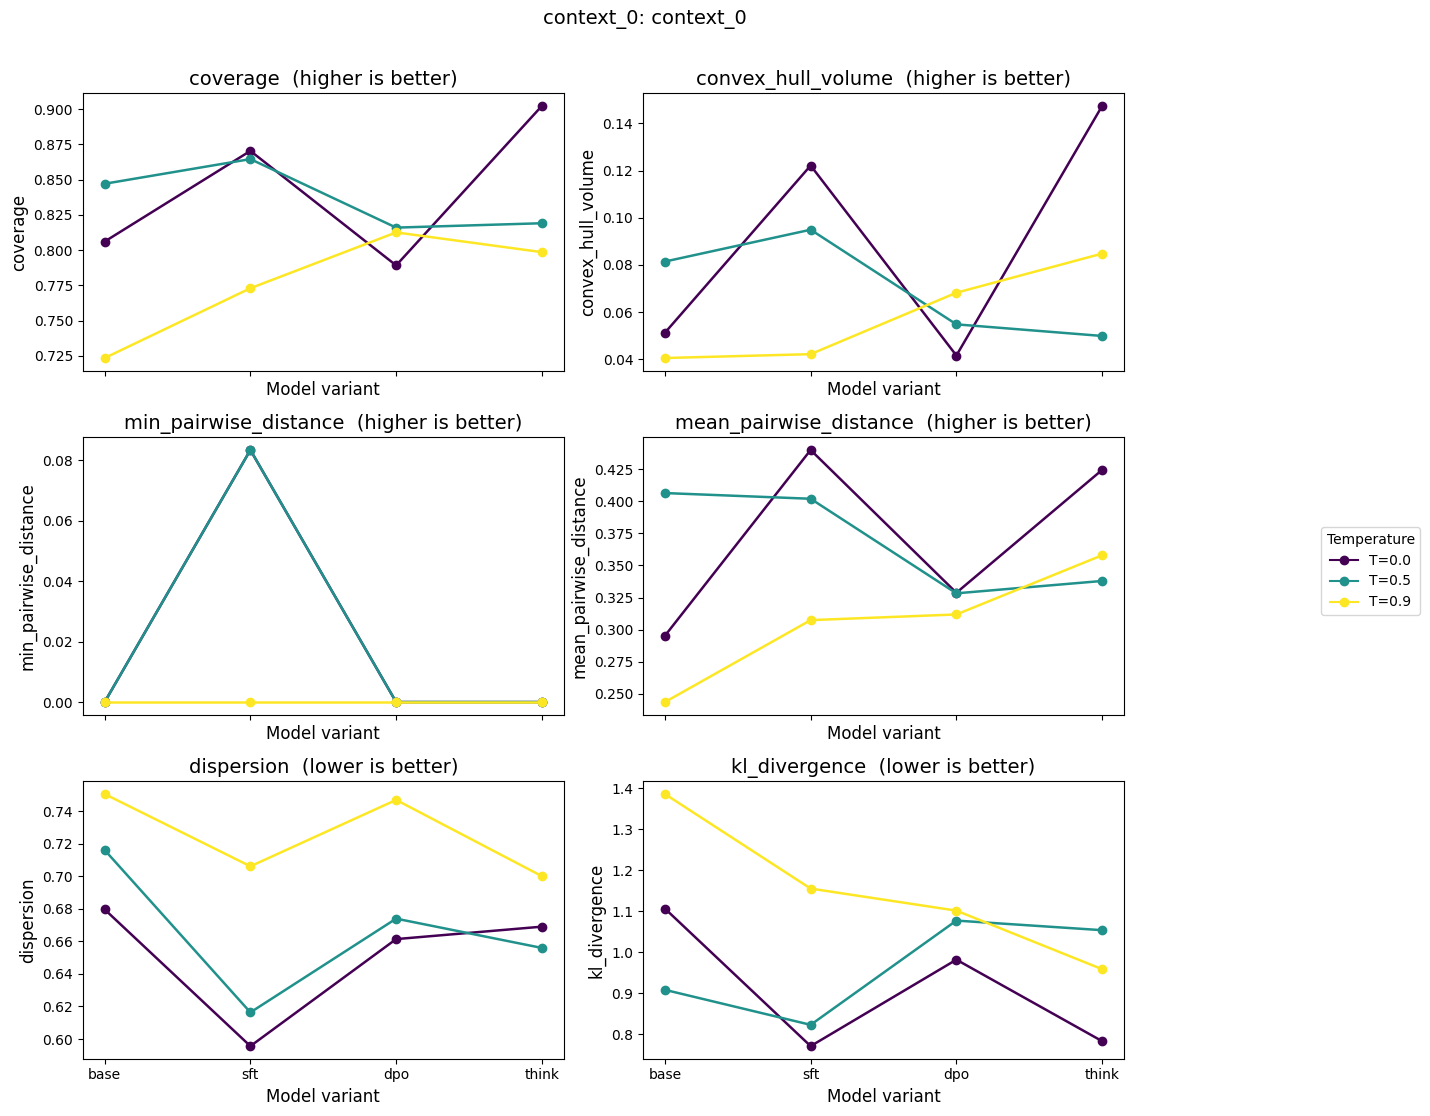


context_1 (american conspiracy theories 2024): no metric data — skipping

context_2 (genz social media politics 2025): no metric data — skipping

context_3 (trojan war achaen morale 1184bc): no metric data — skipping

context_4 (swe ai assistants 2024): no metric data — skipping

context_5 (ww2 civilian sentiment germany 1943): no metric data — skipping


In [72]:
MODEL_VARIANT_ORDER = ["base", "sft", "dpo", "think"]
MODEL_TO_VARIANT = {
    "OLMo-3-1125-32B":       "base",
    "Olmo-3-32B-Think-SFT":  "sft",
    "Olmo-3-32B-Think-DPO":  "dpo",
    "Olmo-3-32B-Think":      "think",
}

METRIC_DIRECTION = {
    "coverage": "higher",
    "convex_hull_volume": "higher",
    "min_pairwise_distance": "higher",
    "mean_pairwise_distance": "higher",
    "dispersion": "lower",
    "kl_divergence": "lower",
    "mean_normalized_diversity_score": "higher",
}

NORM_COLS = [f"{m}_norm" for m in METRIC_COLS]


def _setup_style() -> None:
    if _HAVE_SEABORN:
        sns.set_theme(style="whitegrid")
    plt.rcParams.update(
        {
            "figure.figsize": (12, 8),
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "legend.fontsize": 10,
        }
    )


def _add_variant_col(data: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of *data* with an ordered 'variant' categorical column."""
    out = data.copy()
    out["variant"] = pd.Categorical(
        out["model"].map(MODEL_TO_VARIANT),
        categories=MODEL_VARIANT_ORDER,
        ordered=True,
    )
    return out.dropna(subset=["variant"])


def _temp_colors(temps: list) -> list:
    return plt.cm.viridis([i / max(len(temps) - 1, 1) for i in range(len(temps))])


def _temp_legend_handles(temps: list, colors: list) -> list:
    return [plt.Line2D([], [], marker="o", color=c, label=f"T={t}")
            for c, t in zip(colors, temps)]


# ── Per-axis helpers ────────────────────────────────────────────────────────

def plot_metric_on_axis(metric: str, data: pd.DataFrame, ax: plt.Axes) -> None:
    """Plot *metric* vs model variant (x), one line per temperature."""
    direction = METRIC_DIRECTION.get(metric, "higher")
    temps = sorted(data["temp"].dropna().unique())
    colors = _temp_colors(temps)

    for color, temp in zip(colors, temps):
        subset = data[data["temp"] == temp].sort_values("variant")
        xs, ys = [], []
        for xi, variant in enumerate(MODEL_VARIANT_ORDER):
            row = subset[subset["variant"] == variant]
            if not row.empty:
                xs.append(xi)
                ys.append(row[metric].values[0])
        ax.plot(xs, ys, marker="o", linewidth=1.8, markersize=6, color=color, label=f"T={temp}")

    ax.set_xticks(range(len(MODEL_VARIANT_ORDER)))
    ax.set_xticklabels(MODEL_VARIANT_ORDER)
    ax.set_title(f"{metric}  ({direction} is better)")
    ax.set_xlabel("Model variant")
    ax.set_ylabel(metric)


# ── Figure-level plot functions ─────────────────────────────────────────────

def plot_metrics_grid(metrics: list[str], data: pd.DataFrame,
                      prompt_type: str = "autobiographical",
                      suptitle: str = "") -> None:
    """6-panel grid: each metric vs model variant, one line per temperature."""
    _setup_style()
    vdata = _add_variant_col(data)
    vdata = vdata[vdata["prompt_type"] == prompt_type]

    if vdata.empty:
        print(f"  No data for prompt_type={prompt_type} — skipping grid")
        return

    fig, axes = plt.subplots(3, 2, sharex=True, figsize=(13, 11))
    axes_flat = axes.flatten()

    for ax, metric in zip(axes_flat, metrics):
        plot_metric_on_axis(metric, vdata, ax)

    for ax in axes_flat[len(metrics):]:
        ax.axis("off")

    temps = sorted(vdata["temp"].dropna().unique())
    handles = _temp_legend_handles(temps, _temp_colors(temps))
    fig.legend(handles, [h.get_label() for h in handles],
               title="Temperature", bbox_to_anchor=(1.02, 0.5),
               loc="center left", borderaxespad=0.0)
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, y=1.01)
    plt.tight_layout(rect=(0, 0, 0.88, 1))
    plt.show()


def plot_normalized_evolution(data: pd.DataFrame,
                               prompt_type: str = "autobiographical",
                               suptitle: str = "") -> None:
    """Mean normalized diversity score vs model variant; one line per temperature.
    Error bars show ±1 std across the 6 normalized metric components."""
    evo_df = _add_variant_col(data)
    evo_df = evo_df[evo_df["prompt_type"] == prompt_type].copy()
    evo_df = evo_df.dropna(subset=["mean_normalized_diversity_score"])
    evo_df = evo_df.sort_values(["variant", "temp"])

    if evo_df.empty:
        print(f"  No normalized data for prompt_type={prompt_type} — skipping")
        return

    # Compute std across the 6 normalized metrics for each row
    available_norm = [c for c in NORM_COLS if c in evo_df.columns]
    evo_df["norm_std"] = evo_df[available_norm].std(axis=1, skipna=True)

    _setup_style()
    fig, ax = plt.subplots(figsize=(9, 5))

    temps = sorted(evo_df["temp"].unique())
    colors = _temp_colors(temps)

    for color, temp in zip(colors, temps):
        subset = evo_df[evo_df["temp"] == temp].sort_values("variant")
        x_vals = [MODEL_VARIANT_ORDER.index(v) for v in subset["variant"]]
        ax.errorbar(
            x_vals,
            subset["mean_normalized_diversity_score"],
            yerr=subset["norm_std"],
            marker="o", color=color, label=f"T={temp}",
            linewidth=2, markersize=8, capsize=4, capthick=1.5,
        )

    ax.set_xlabel("Model variant")
    ax.set_ylabel("Mean normalized diversity score (higher is better)")
    title = f"Diversity vs model evolution  ({prompt_type} prompt)"
    if suptitle:
        title = f"{suptitle}\n{title}"
    ax.set_title(title)
    ax.set_xticks(range(len(MODEL_VARIANT_ORDER)))
    ax.set_xticklabels(MODEL_VARIANT_ORDER)
    ax.legend(title="Temperature", bbox_to_anchor=(1.02, 0.5),
              loc="center left", borderaxespad=0.0)
    plt.tight_layout(rect=(0, 0, 0.88, 1))
    plt.show()


# ── Generate figures for each context ───────────────────────────────────────
for _cid, _label, _ in CONTEXT_DIRS:
    ctx_data = plot_df[plot_df["context_id"] == _cid]
    if ctx_data.empty:
        print(f"\ncontext_{_cid} ({_label}): no metric data — skipping")
        continue
    print(f"\n{'='*70}")
    print(f"context_{_cid}: {_label}")
    print(f"{'='*70}")
    plot_metrics_grid(METRIC_COLS, ctx_data,
                      suptitle=f"context_{_cid}: {_label}")

In [73]:
def plot_metric_vs_temp(metric: str, data: pd.DataFrame,
                        suptitle: str = "") -> None:
    """Plot a single metric vs temperature, one line per model_prompt."""
    if metric not in data.columns:
        raise KeyError(f"Missing metric column: {metric}")

    _setup_style()

    direction = METRIC_DIRECTION.get(metric, "higher")
    fig, ax = plt.subplots(figsize=(10, 6))

    plot_metric_on_axis(metric, data, ax)

    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        for label, _ in data.groupby("model_prompt", sort=False):
            handles.append(plt.Line2D([], [], marker="o", linestyle="-"))
            labels.append(label)

    ax.legend(handles, labels, title="model+prompt_type", bbox_to_anchor=(1.02, 0.5),
              loc="center left", borderaxespad=0.0)
    if suptitle:
        ax.set_title(f"{suptitle}\n{ax.get_title()}")
    plt.tight_layout(rect=(0, 0, 0.78, 1))
    plt.show()

In [74]:
# Direction-aware normalized composite across the 6 metrics.
# Normalization is computed *per context* so scores are comparable within a context.

lower_is_better = {"dispersion", "kl_divergence"}

norm_frames = []
for _cid in plot_df["context_id"].unique():
    ctx_slice = plot_df[plot_df["context_id"] == _cid].copy()

    for metric in METRIC_COLS:
        vals = pd.to_numeric(ctx_slice[metric], errors="coerce")
        vmin, vmax = vals.min(), vals.max()

        if pd.isna(vmin) or pd.isna(vmax) or vmax == vmin:
            ctx_slice[f"{metric}_norm"] = 0.5
        elif metric in lower_is_better:
            ctx_slice[f"{metric}_norm"] = (vmax - vals) / (vmax - vmin)
        else:
            ctx_slice[f"{metric}_norm"] = (vals - vmin) / (vmax - vmin)

    norm_cols = [f"{m}_norm" for m in METRIC_COLS]
    ctx_slice["mean_normalized_diversity_score"] = ctx_slice[norm_cols].mean(axis=1, skipna=True)
    norm_frames.append(ctx_slice)

norm_df = pd.concat(norm_frames, ignore_index=True) if norm_frames else pd.DataFrame()

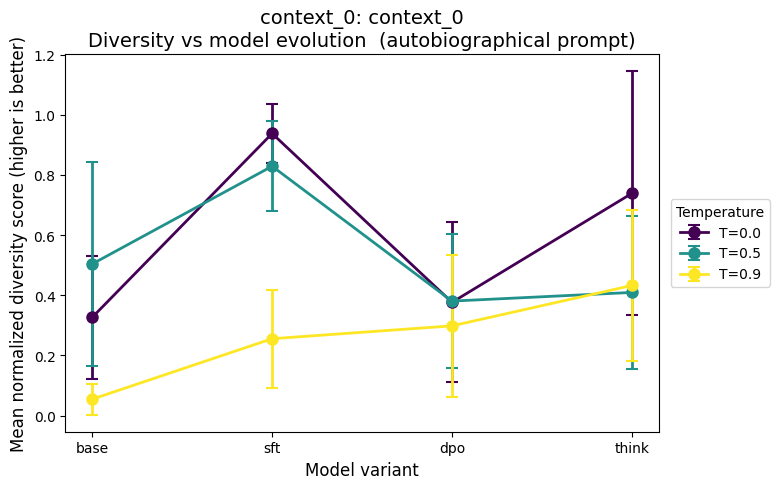

In [75]:
for _cid, _label, _ in CONTEXT_DIRS:
    ctx_data = norm_df[norm_df["context_id"] == _cid]
    if ctx_data.empty or "mean_normalized_diversity_score" not in ctx_data.columns:
        continue
    plot_normalized_evolution(ctx_data, suptitle=f"context_{_cid}: {_label}")

## Checkpoint sweep — diversity vs training steps

Loads `04_diversity_metric` artifacts from `context_*/checkpoints/`, extracts the training step from the revision tag (e.g. `1e-4-step3000` → step 3000), and plots each of the six diversity metrics vs step — **one set of figures per context**.  
Legend encodes temperature; x-axis is the checkpoint step number.

In [76]:
import re as _re

_CKPT_STEP_RE = _re.compile(r"[-_]step(?P<step>\d+)")


def _parse_step(model_name: str) -> int | None:
    m = _CKPT_STEP_RE.search(model_name)
    return int(m.group("step")) if m else None


# ── Load checkpoint artifacts per context ───────────────────────────────────
ckpt_frames = []
for _cid, _label, _path in CONTEXT_DIRS:
    ckpt_dir = _path / "checkpoints"
    if not ckpt_dir.exists():
        continue
    ckpt_files = sorted(ckpt_dir.glob("04_diversity_metric*.json"))
    if not ckpt_files:
        continue
    try:
        _ckpt = load_diversity_metric_artifacts(ckpt_dir, context_id=_cid, context_label=_label)
        _ckpt["step"] = _ckpt["model"].apply(_parse_step)
        _ckpt = _ckpt.dropna(subset=["step"])
        _ckpt["step"] = _ckpt["step"].astype(int)
        _ckpt = _ckpt.sort_values(["step", "temp"]).reset_index(drop=True)
        ckpt_frames.append(_ckpt)
        print(f"  context_{_cid}: {len(_ckpt)} checkpoint artifact(s)")
    except FileNotFoundError:
        pass

if ckpt_frames:
    ckpt_df = pd.concat(ckpt_frames, ignore_index=True)
    print(f"\nTotal: {len(ckpt_df)} checkpoint artifact(s) across {ckpt_df['context_id'].nunique()} context(s)")
    display(ckpt_df[["context_id", "context_label", "model", "step", "temp", "prompt_type"] + METRIC_COLS])
else:
    ckpt_df = pd.DataFrame()
    print("No checkpoint artifacts found in any context.")

  context_0: 4 checkpoint artifact(s)

Total: 4 checkpoint artifact(s) across 1 context(s)


,context_id,context_label,model,step,temp,prompt_type,coverage,convex_hull_volume,min_pairwise_distance,mean_pairwise_distance,dispersion,kl_divergence
0,0,context_0,Olmo-3-32B-Think-SFT_1e-4-step1000,1000,0.5,autobiographical,0.8403,0.081983,0.0,0.376743,0.619112,0.934779
1,0,context_0,Olmo-3-32B-Think-SFT_1e-4-step3000,3000,0.5,autobiographical,0.8217,0.064236,0.0,0.362568,0.700001,1.039087
2,0,context_0,Olmo-3-32B-Think-SFT_1e-4-step5000,5000,0.5,autobiographical,0.8264,0.073978,0.0,0.312189,0.694554,1.099034
3,0,context_0,Olmo-3-32B-Think-SFT_1e-4-step7000,7000,0.5,autobiographical,0.7218,0.046586,0.0,0.290251,0.735730,1.198872


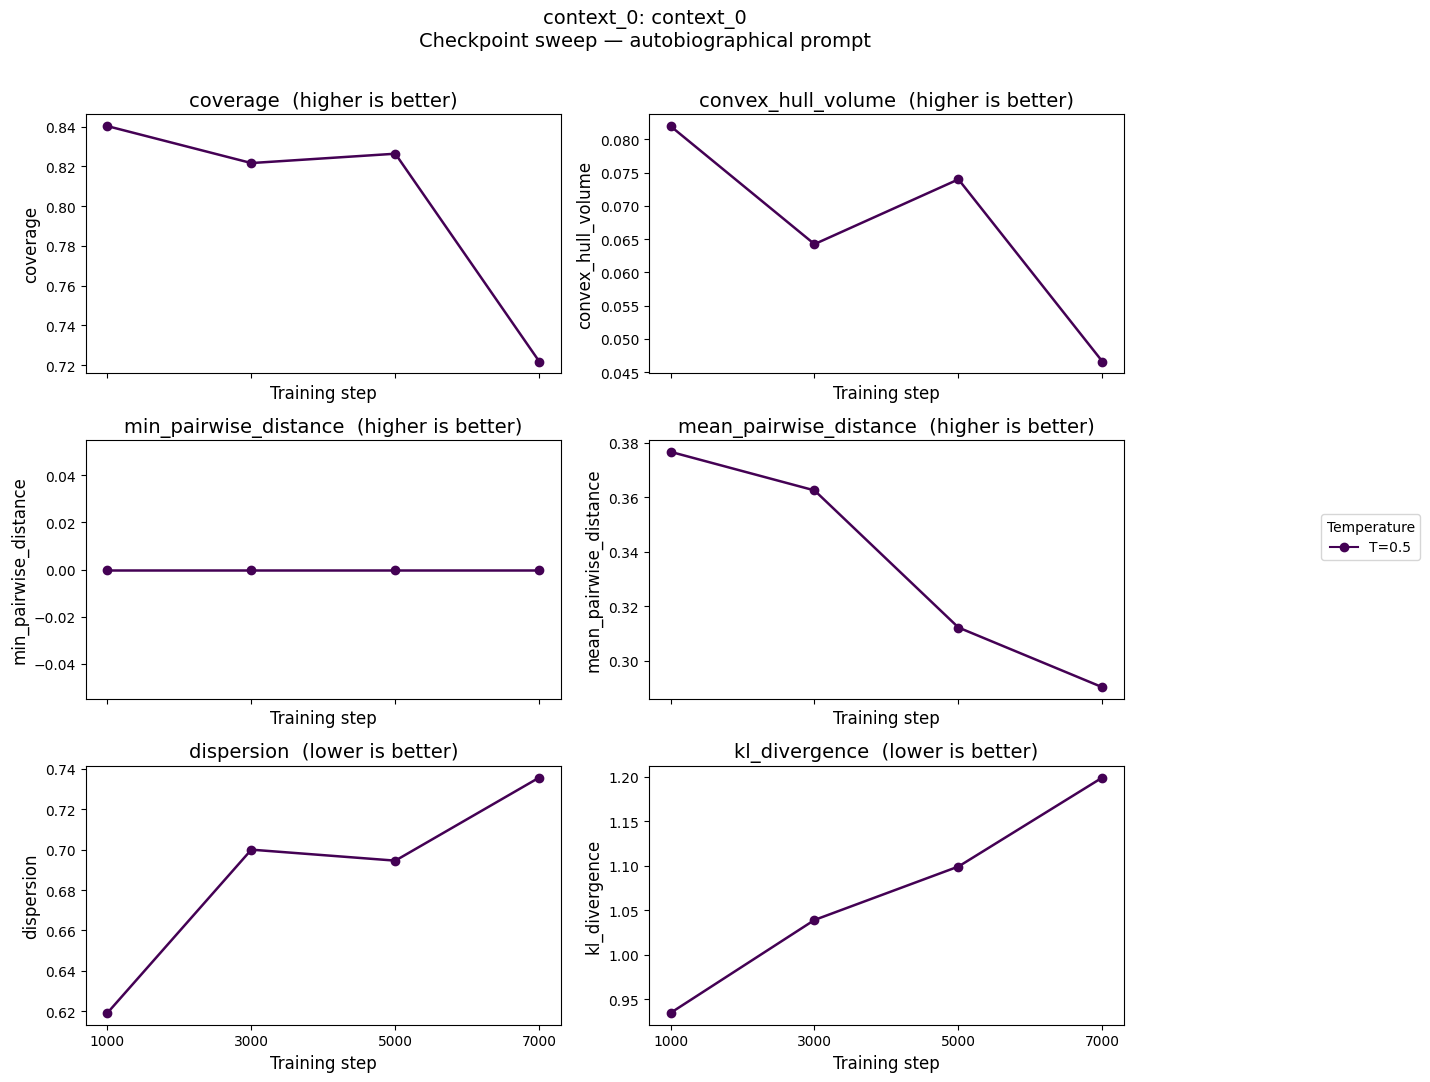

In [77]:
def plot_checkpoint_metric_on_axis(metric: str, data: pd.DataFrame, ax: plt.Axes) -> None:
    """Plot *metric* vs training step (x); one line per temperature."""
    direction = METRIC_DIRECTION.get(metric, "higher")
    temps = sorted(data["temp"].dropna().unique())
    colors = _temp_colors(temps)
    steps = sorted(data["step"].unique())

    for color, temp in zip(colors, temps):
        subset = data[data["temp"] == temp].sort_values("step")
        ax.plot(subset["step"], subset[metric],
                marker="o", linewidth=1.8, markersize=6, color=color, label=f"T={temp}")

    ax.set_xticks(steps)
    ax.set_title(f"{metric}  ({direction} is better)")
    ax.set_xlabel("Training step")
    ax.set_ylabel(metric)


def plot_checkpoint_metrics_grid(metrics: list[str], data: pd.DataFrame,
                                  prompt_type: str = "autobiographical",
                                  suptitle: str = "") -> None:
    """6-panel grid: each metric vs training step; one line per temperature."""
    _setup_style()
    cdata = data[data["prompt_type"] == prompt_type].copy()

    if cdata.empty:
        print(f"  No checkpoint data for prompt_type={prompt_type} — skipping")
        return

    fig, axes = plt.subplots(3, 2, sharex=True, figsize=(13, 11))
    axes_flat = axes.flatten()

    for ax, metric in zip(axes_flat, metrics):
        plot_checkpoint_metric_on_axis(metric, cdata, ax)

    for ax in axes_flat[len(metrics):]:
        ax.axis("off")

    temps = sorted(cdata["temp"].dropna().unique())
    handles = _temp_legend_handles(temps, _temp_colors(temps))
    fig.legend(handles, [h.get_label() for h in handles],
               title="Temperature", bbox_to_anchor=(1.02, 0.5),
               loc="center left", borderaxespad=0.0)
    title = f"Checkpoint sweep — {prompt_type} prompt"
    if suptitle:
        title = f"{suptitle}\n{title}"
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=(0, 0, 0.88, 0.97))
    plt.show()


def plot_checkpoint_normalized_evolution(data: pd.DataFrame,
                                          prompt_type: str = "autobiographical",
                                          suptitle: str = "") -> None:
    """Mean normalized diversity score vs training step; one line per temperature.
    Error bars show ±1 std across the 6 normalized metric components."""
    cdata = data[data["prompt_type"] == prompt_type].copy()
    cdata = cdata.dropna(subset=["step", "mean_normalized_diversity_score"])

    if cdata.empty:
        return

    available_norm = [c for c in NORM_COLS if c in cdata.columns]
    cdata["norm_std"] = cdata[available_norm].std(axis=1, skipna=True)

    _setup_style()
    fig, ax = plt.subplots(figsize=(9, 5))

    temps = sorted(cdata["temp"].dropna().unique())
    colors = _temp_colors(temps)

    for color, temp in zip(colors, temps):
        subset = cdata[cdata["temp"] == temp].sort_values("step")
        ax.errorbar(
            subset["step"],
            subset["mean_normalized_diversity_score"],
            yerr=subset["norm_std"],
            marker="o", linewidth=2, markersize=8, color=color, label=f"T={temp}",
            capsize=4, capthick=1.5,
        )

    ax.set_xlabel("Training step")
    ax.set_ylabel("Mean normalized diversity score (higher is better)")
    title = f"Diversity vs training step — {prompt_type} prompt"
    if suptitle:
        title = f"{suptitle}\n{title}"
    ax.set_title(title)
    ax.legend(title="Temperature", bbox_to_anchor=(1.02, 0.5),
              loc="center left", borderaxespad=0.0)
    plt.tight_layout(rect=(0, 0, 0.88, 1))
    plt.show()


# ── Plot checkpoint grids per context ───────────────────────────────────────
if not ckpt_df.empty:
    for _cid in ckpt_df["context_id"].unique():
        _label = ckpt_df.loc[ckpt_df["context_id"] == _cid, "context_label"].iloc[0]
        ctx_ckpt = ckpt_df[ckpt_df["context_id"] == _cid]
        plot_checkpoint_metrics_grid(METRIC_COLS, ctx_ckpt,
                                     suptitle=f"context_{_cid}: {_label}")

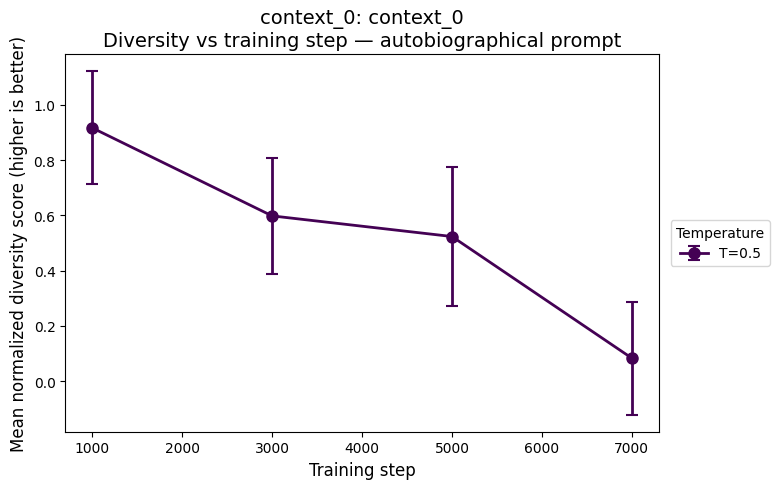

In [78]:
# Compute per-checkpoint normalized scores (min-max within each context's checkpoint slice).
if not ckpt_df.empty:
    _lower_is_better = {"dispersion", "kl_divergence"}
    ckpt_norm_frames = []

    for _cid in ckpt_df["context_id"].unique():
        ctx_slice = ckpt_df[ckpt_df["context_id"] == _cid].copy()
        for metric in METRIC_COLS:
            vals = pd.to_numeric(ctx_slice[metric], errors="coerce")
            vmin, vmax = vals.min(), vals.max()
            if pd.isna(vmin) or pd.isna(vmax) or vmax == vmin:
                ctx_slice[f"{metric}_norm"] = 0.5
            elif metric in _lower_is_better:
                ctx_slice[f"{metric}_norm"] = (vmax - vals) / (vmax - vmin)
            else:
                ctx_slice[f"{metric}_norm"] = (vals - vmin) / (vmax - vmin)

        ctx_slice["mean_normalized_diversity_score"] = (
            ctx_slice[[f"{m}_norm" for m in METRIC_COLS]].mean(axis=1, skipna=True)
        )
        ckpt_norm_frames.append(ctx_slice)

    ckpt_norm_df = pd.concat(ckpt_norm_frames, ignore_index=True)

    for _cid in ckpt_norm_df["context_id"].unique():
        _label = ckpt_norm_df.loc[ckpt_norm_df["context_id"] == _cid, "context_label"].iloc[0]
        ctx_data = ckpt_norm_df[ckpt_norm_df["context_id"] == _cid]
        plot_checkpoint_normalized_evolution(ctx_data,
                                             suptitle=f"context_{_cid}: {_label}")
else:
    print("No checkpoint data to normalize.")

## Progressive Conditional Surprise — D bands & ak curves

Loads the `05_diversity_metric_conditionalsurprise_*.json` artifacts from each `context_*/` folder and plots per context:

1. **D bands** — diversity rate D = C x E with the uncertainty band [D-, D+] = [C-xE, C+xE] vs temperature
2. **ak curves** — the Progressive Conditional Surprise curve per run (bits/byte as each successive response is conditioned on all prior ones)

In [ ]:
def load_conditional_surprise_artifacts(base_dir: Path, context_id: int | None = None,
                                         context_label: str | None = None) -> pd.DataFrame:
    files = sorted(base_dir.glob("05_diversity_metric_conditionalsurprise_*.json"))
    if not files:
        raise FileNotFoundError(
            f"No 05_diversity_metric_conditionalsurprise_*.json files found in {base_dir}"
        )

    rows = []
    for p in files:
        with p.open("r", encoding="utf-8") as f:
            data = json.load(f)

        stage2_file = data.get("stage2_file", "")
        parsed = _parse_stage2_id(stage2_file) if stage2_file else {}
        metrics = data.get("metrics", {})

        rows.append({
            "context_id": context_id,
            "context_label": context_label,
            "artifact_path": str(p.relative_to(REPO_ROOT)),
            "stage2_file": stage2_file,
            "model":       parsed.get("model", "unknown"),
            "temp":        parsed.get("temp", float("nan")),
            "prompt_type": parsed.get("prompt_type", "unknown"),
            "n_responses": data.get("n_responses"),
            "diversity_rate":        metrics.get("diversity_rate"),
            "diversity_lower":       metrics.get("diversity_lower"),
            "diversity_upper":       metrics.get("diversity_upper"),
            "diversity_total":       metrics.get("diversity_total"),
            "coherence":             metrics.get("coherence"),
            "coherence_spread":      metrics.get("coherence_spread"),
            "excess_entropy_rate":   metrics.get("excess_entropy_rate"),
            "ak_curve":              metrics.get("ak_curve", []),
        })

    cs_df = pd.DataFrame(rows)
    cs_df["model_prompt"] = cs_df["model"].astype(str) + "+" + cs_df["prompt_type"].astype(str)
    cs_df["temp"] = pd.to_numeric(cs_df["temp"], errors="coerce")
    cs_df = cs_df.sort_values(["model_prompt", "temp"], na_position="last").reset_index(drop=True)
    return cs_df


# ── Load conditional surprise across all contexts ───────────────────────────
cs_frames = []
for _cid, _label, _path in CONTEXT_DIRS:
    try:
        _cs = load_conditional_surprise_artifacts(_path, context_id=_cid, context_label=_label)
        cs_frames.append(_cs)
        print(f"  context_{_cid}: {len(_cs)} conditional surprise artifact(s)")
    except FileNotFoundError:
        pass

if cs_frames:
    cs_df = pd.concat(cs_frames, ignore_index=True)
    print(f"\nTotal: {len(cs_df)} conditional surprise artifact(s)")
    display(cs_df[["context_id", "context_label", "model", "temp", "prompt_type",
                    "diversity_rate", "diversity_lower", "diversity_upper",
                    "coherence", "excess_entropy_rate"]])
else:
    cs_df = pd.DataFrame()
    print("No conditional surprise artifacts found.")

In [ ]:
# ── Diversity bands: D ± [D⁻, D⁺] vs model evolution — per context ──────────

def plot_diversity_bands(cs_data: pd.DataFrame, suptitle: str = "") -> None:
    """D bands plot for a single context's conditional surprise data."""
    _setup_style()

    cs_plot = cs_data.copy()
    cs_plot["variant"] = cs_plot["model"].map(MODEL_TO_VARIANT)
    cs_plot = cs_plot.dropna(subset=["variant", "diversity_rate"])
    cs_plot = cs_plot[cs_plot["prompt_type"] == "autobiographical"]
    cs_plot["variant"] = pd.Categorical(cs_plot["variant"], categories=MODEL_VARIANT_ORDER, ordered=True)
    cs_plot = cs_plot.sort_values(["temp", "variant"])

    if cs_plot.empty:
        print(f"  No autobiographical data for D-bands — skipping")
        return

    temps_cs = sorted(cs_plot["temp"].dropna().unique())
    cs_colors = plt.cm.viridis([i / max(len(temps_cs) - 1, 1) for i in range(len(temps_cs))])

    fig, ax = plt.subplots(figsize=(9, 5))
    x_pos = list(range(len(MODEL_VARIANT_ORDER)))

    for color, temp in zip(cs_colors, temps_cs):
        subset = cs_plot[cs_plot["temp"] == temp].sort_values("variant")
        xs, ds, d_los, d_his = [], [], [], []
        for xi, variant in enumerate(MODEL_VARIANT_ORDER):
            row = subset[subset["variant"] == variant]
            if row.empty:
                continue
            xs.append(xi)
            ds.append(row["diversity_rate"].values[0])
            d_los.append(row["diversity_lower"].values[0])
            d_his.append(row["diversity_upper"].values[0])

        ax.plot(xs, ds, marker="o", linewidth=2, markersize=8, color=color, label=f"T={temp}")
        ax.fill_between(xs, d_los, d_his, alpha=0.18, color=color)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(MODEL_VARIANT_ORDER, fontsize=11)
    ax.set_xlabel("Model variant")
    ax.set_ylabel("Diversity rate  D = C × E  (bits/byte)")
    title = "Progressive Conditional Surprise — D with coherence band [D⁻, D⁺]\n(autobiographical prompt)"
    if suptitle:
        title = f"{suptitle}\n{title}"
    ax.set_title(title)
    ax.legend(title="Temperature", bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0.0)
    plt.tight_layout(rect=(0, 0, 0.88, 1))
    plt.show()


if not cs_df.empty:
    for _cid in cs_df["context_id"].unique():
        _label = cs_df.loc[cs_df["context_id"] == _cid, "context_label"].iloc[0]
        ctx_cs = cs_df[cs_df["context_id"] == _cid]
        plot_diversity_bands(ctx_cs, suptitle=f"context_{_cid}: {_label}")

In [ ]:
# ── ak curves: Progressive Conditional Surprise per run — per context ────────

def plot_ak_curves(cs_data: pd.DataFrame, suptitle: str = "") -> None:
    """ak curve subplots (one per model) for a single context."""
    models = sorted(cs_data["model"].unique())
    n_models = len(models)
    if n_models == 0:
        return

    temps_sorted = sorted(cs_data["temp"].dropna().unique())
    temp_colors = plt.cm.viridis([i / max(len(temps_sorted) - 1, 1) for i in range(len(temps_sorted))])
    temp_color_map = dict(zip(temps_sorted, temp_colors))

    _setup_style()
    fig, axes = plt.subplots(n_models, 1, figsize=(11, 4 * n_models), sharex=True, sharey=False)
    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        rows = cs_data[cs_data["model"] == model].sort_values("temp")
        for _, row in rows.iterrows():
            curve = row["ak_curve"]
            if not curve:
                continue
            ks = list(range(1, len(curve) + 1))
            color = temp_color_map.get(row["temp"], "grey")
            ax.plot(ks, curve, marker=".", linewidth=1.5, markersize=4,
                    color=color, label=f"T={row['temp']}")

        ax.set_title(f"{model}  —  ak curve  (bits/byte per response)")
        ax.set_ylabel("a_k  (bits/byte)")
        ax.axhline(rows["ak_curve"].apply(lambda c: c[-1] if c else float("nan")).mean(),
                    linestyle="--", linewidth=0.8, color="grey", label="mean a_inf")

        handles = [plt.Line2D([], [], color=temp_color_map[t], marker=".", label=f"T={t}")
                   for t in temps_sorted]
        handles.append(plt.Line2D([], [], linestyle="--", color="grey", label="mean a_inf"))
        ax.legend(handles=handles, title="Temperature", loc="upper right", fontsize=9)

    axes[-1].set_xlabel("Response index  k")
    main_title = "Progressive Conditional Surprise  —  ak curves"
    if suptitle:
        main_title = f"{suptitle}\n{main_title}"
    plt.suptitle(main_title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


if not cs_df.empty:
    for _cid in cs_df["context_id"].unique():
        _label = cs_df.loc[cs_df["context_id"] == _cid, "context_label"].iloc[0]
        ctx_cs = cs_df[cs_df["context_id"] == _cid]
        plot_ak_curves(ctx_cs, suptitle=f"context_{_cid}: {_label}")